In [10]:
import pandas as pd
from datetime import date, timedelta
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import requests

In [20]:
end_date = date.today()
start_date = end_date - timedelta(days=5)
S0 = yf.download('PETR4.SA', start=start_date, end = end_date)['Close'].tail(1)
if hasattr(S0, "iloc"):
    S0 = S0.iloc[0]

S0 = float(S0)
UI = 1.30

K = S0 * UI

[*********************100%***********************]  1 of 1 completed
C:\Users\lucab\AppData\Local\Temp\ipykernel_21864\2041527104.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(S0)


In [12]:
def listar_opcoes(ativo_obj, vencimento):
    url = (
        f'https://opcoes.net.br/listaopcoes/completa?'
        f'idAcao={ativo_obj}&listarVencimentos=false&cotacoes=true&vencimentos={vencimento}'
    )

    r = requests.get(url).json()

    l = [
        [
            ativo_obj,
            vencimento,
            i[0].split('_')[0],
            i[2],
            i[3],
            i[5],
            i[8]
        ]
        for i in r['data']['cotacoesOpcoes']
    ]

    return pd.DataFrame(
        l,
        columns=['ativo_obj', 'vencimento', 'ativo', 'tipo', 'modelo', 'strike', 'preco']
    )


def listar_opcoes_365_dias(ativo_obj):
    hoje = pd.Timestamp.today().normalize()

    dfs = []

    for i in range(365):
        data = hoje + pd.Timedelta(days=i)
        vencimento = data.strftime('%Y-%m-%d')

        try:
            df = listar_opcoes(ativo_obj, vencimento)

            if not df.empty:
                df['vencimento'] = pd.to_datetime(df['vencimento'])

                df['dias_uteis_vencimento'] = df['vencimento'].apply(
                    lambda x: len(pd.bdate_range(start=hoje, end=x)) - 1
                )

                dfs.append(df)

        except Exception:
            pass

    if dfs:
        return pd.concat(dfs, ignore_index=True)

    return pd.DataFrame(
        columns=[
            'ativo_obj',
            'vencimento',
            'ativo',
            'tipo',
            'modelo',
            'strike',
            'preco',
            'dias_uteis_vencimento'
        ]
    )

In [16]:
ATIVO = listar_opcoes_365_dias('PETR4').dropna()
ATIVO = ATIVO[ATIVO["tipo"] == 'CALL']

# =========================
# FILTRO DE STRIKES PRÓXIMOS DA BARREIRA
# =========================

S0_float = float(S0.iloc[0]) if hasattr(S0, "iloc") else float(S0)

H = S0_float * UI

ATIVO["strike"] = pd.to_numeric(
    ATIVO["strike"],
    errors="coerce"
)

ATIVO = ATIVO[
    (ATIVO["strike"] >= H * 0.80) &
    (ATIVO["strike"] <= H * 1.20)
]

C:\Users\lucab\AppData\Local\Temp\ipykernel_21864\523889174.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0_float = float(S0.iloc[0]) if hasattr(S0, "iloc") else float(S0)


In [21]:
from io import StringIO

ANBIMA_URL = "https://www.anbima.com.br/informacoes/est-termo/CZ-down.asp"

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.anbima.com.br/",
}


def to_float_br(x):
    if isinstance(x, str):
        x = x.replace(".", "").replace(",", ".")
    return float(x)


def buscar_curva_parametrica_anbima(data_ref=None, max_du=2520):
    if data_ref is None:
        hoje = date.today()

        if hoje.weekday() == 0:
            data_ref = hoje - timedelta(days=3)
        elif hoje.weekday() == 6:
            data_ref = hoje - timedelta(days=2)
        else:
            data_ref = hoje - timedelta(days=1)

        data_ref = data_ref.strftime("%d/%m/%Y")

    params = {
        "Tipo": "ETTJPreFixado",
        "DataRef": data_ref,
        "Instrucao": "None",
    }

    resp = requests.get(
        ANBIMA_URL,
        params=params,
        headers=HEADERS,
        timeout=15
    )

    resp.raise_for_status()

    raw = resp.content.decode("latin-1")

    lines = [
        l for l in raw.splitlines()
        if l.strip() and not l.startswith("(*")
    ]

    sep = ";" if ";" in lines[0] else ","

    df_param = pd.read_csv(
        StringIO("\n".join(lines)),
        sep=sep,
        decimal=",",
        thousands="."
    )

    df_param.columns = [c.strip() for c in df_param.columns]

    row = df_param.iloc[0]

    beta1 = to_float_br(row["Beta 1"])
    beta2 = to_float_br(row["Beta 2"])
    beta3 = to_float_br(row["Beta 3"])
    beta4 = to_float_br(row["Beta 4"])
    lambda1 = to_float_br(row["Lambda 1"])
    lambda2 = to_float_br(row["Lambda 2"])

    curva = []

    for du in range(1, max_du + 1):
        t = du / 252

        termo1 = (1 - np.exp(-lambda1 * t)) / (lambda1 * t)
        termo2 = termo1 - np.exp(-lambda1 * t)
        termo3 = ((1 - np.exp(-lambda2 * t)) / (lambda2 * t)) - np.exp(-lambda2 * t)

        taxa_aa_decimal = (
            beta1
            + beta2 * termo1
            + beta3 * termo2
            + beta4 * termo3
        )

        curva.append([du, t, taxa_aa_decimal])

    return pd.DataFrame(
        curva,
        columns=["dias_uteis_vencimento", "T", "r"]
    )


curva_juros = buscar_curva_parametrica_anbima()

ATIVO["dias_uteis_vencimento"] = pd.to_numeric(
    ATIVO["dias_uteis_vencimento"],
    errors="coerce"
)

ATIVO = ATIVO.dropna(subset=["dias_uteis_vencimento"])

ATIVO["dias_uteis_vencimento"] = ATIVO["dias_uteis_vencimento"].astype(int)
curva_juros["dias_uteis_vencimento"] = curva_juros["dias_uteis_vencimento"].astype(int)

ATIVO = ATIVO.drop(columns=["T", "r"], errors="ignore")

ATIVO = ATIVO.merge(
    curva_juros,
    on="dias_uteis_vencimento",
    how="left"
)

# =========================
# AJUSTES PARA BLACK-SCHOLES
# =========================

ATIVO["S0"] = float(S0)

ATIVO["strike"] = pd.to_numeric(
    ATIVO["strike"],
    errors="coerce"
)

ATIVO["preco"] = pd.to_numeric(
    ATIVO["preco"],
    errors="coerce"
)

ATIVO = ATIVO.dropna(
    subset=["S0", "strike", "preco", "T", "r"]
)

ATIVO[
    ["ativo", "S0", "strike", "preco", "dias_uteis_vencimento", "T", "r"]
]

ATIVO[["ativo", "vencimento", "strike", "preco", "dias_uteis_vencimento", "T", "r"]]

,ativo,vencimento,strike,preco,dias_uteis_vencimento,T,r
0,PETRD570W5,2026-04-30,56.46,0.01,1,0.003968,0.143557
1,PETRD575W5,2026-04-30,56.96,0.01,1,0.003968,0.143557
2,PETRD580W5,2026-04-30,57.46,0.01,1,0.003968,0.143557
3,PETRD585W5,2026-04-30,57.96,0.01,1,0.003968,0.143557
4,PETRD590W5,2026-04-30,58.46,0.01,1,0.003968,0.143557
...,...,...,...,...,...,...,...
231,PETRB684,2027-02-19,68.46,2.28,212,0.841270,0.140277
232,PETRD51,2027-04-16,49.46,8.07,252,1.000000,0.139953
233,PETRD56,2027-04-16,55.46,4.50,252,1.000000,0.139953
234,PETRD585,2027-04-16,57.96,3.68,252,1.000000,0.139953


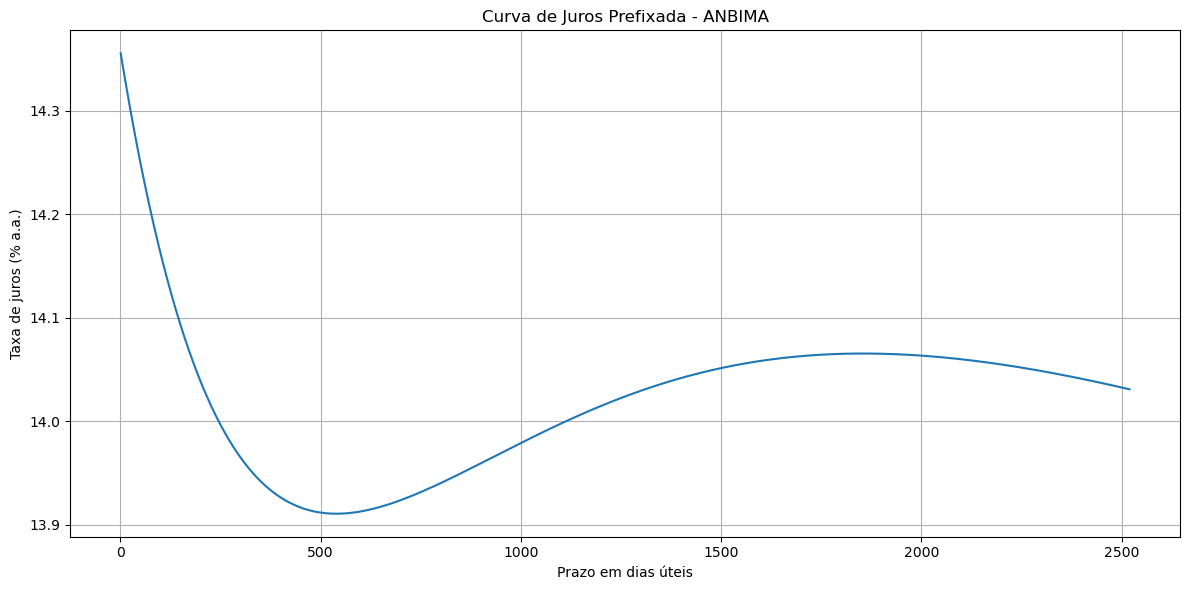

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    curva_juros["dias_uteis_vencimento"],
    curva_juros["r"] * 100
)

plt.xlabel("Prazo em dias úteis")
plt.ylabel("Taxa de juros (% a.a.)")
plt.title("Curva de Juros Prefixada - ANBIMA")

plt.grid(True)
plt.tight_layout()
plt.show()